# (01) Negative Binomial Sweep (ICML rebuttal)

device = ```cuda:2```

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from mcfe.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## Load runs

In [3]:
import wandb
import pandas as pd

api = wandb.Api()

TAG = "sweep_icml_mar29"
runs = api.runs(
    "pal-lab/MCFE",
    filters={
        "tags": TAG,
        "state": "finished",
    },
)

records = []
for run in tqdm(runs):
    cfg = run.config
    summary = run.summary

    recon_mode = cfg.get("recon_mode", "exact")

    if recon_mode == "exact":
        method = "exact"
        temp = None
    else:
        indicator = cfg.get("indicator_approx", "?")
        method = f"EAT_{indicator}"
        temp = cfg.get("temp_stop", None)

    fit_alpha = cfg.get("fit_alpha", False)
    alpha_min = summary.get("coeffs/alpha_min", None)

    if fit_alpha:
        alpha_label = f"fit ({alpha_min:.2f})" if alpha_min is not None else "fit"
    else:
        init = cfg.get("log_alpha_init", "?")
        alpha_label = f"fixed(log={init}) ({alpha_min:.2f})" if alpha_min is not None else f"fixed(log={init})"

    elbo = summary.get("eval/elbo", None)

    records.append({
        "run_id": run.id,
        "method": method,
        "temp": temp,
        "alpha": alpha_label,
        "seed": cfg.get("seed", None),
        "elbo": elbo,
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} runs")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


  0%|          | 0/51 [00:00<?, ?it/s]

Loaded 51 runs

In [4]:
print(df.head(20))

run_id     method      temp         alpha  seed        elbo
0   0nbm94ls      exact       NaN  fit (397.75)     1  167.471954
1   im54jb9h      exact       NaN  fit (411.24)     0  167.325851
2   7kbqat63  EAT_cubic  0.000001  fit (107.20)     0  184.586243
3   uosr4fmn      exact       NaN  fit (303.85)     2  167.307663
4   opa0l2bo  EAT_cubic  0.000001  fit (115.83)     2  184.474442
5   ru7wx0ur  EAT_cubic  0.000001  fit (101.45)     1  184.886963
6   or3gun54  EAT_cubic  0.001000  fit (118.13)     1  167.832535
7   h2suikdg  EAT_cubic  0.001000   fit (96.04)     0  167.756287
8   nvmkzwmv  EAT_cubic  0.010000  fit (113.86)     0  167.513428
9   p2075ite  EAT_cubic  0.001000  fit (103.26)     2  167.785629
10  lin1pqi1  EAT_cubic  0.010000  fit (108.39)     2  167.485718
11  yr0p33dk  EAT_cubic  0.010000  fit (120.62)     1  167.526855
12  1piejhey  EAT_cubic  0.020000  fit (123.18)     1  167.541763
13  pd9pg66z  EAT_cubic  0.020000  fit (100.47)     0  167.487289
14  isrim59r  EAT_cubic  0.050000  fit (127.70)     0  167.395599
15  srhe3s1b  EAT_cubic  0.020000   fit (94.87)     2  167.435226
16  slxw9tk1  EAT_cubic  0.050000  fit (118.47)     2  167.399963
17  simdx28p  EAT_cubic  0.050000  fit (114.85)     1  167.604492
18  03panmel  EAT_cubic  0.100000  fit (114.48)     0  167.533142
19  f6ahe76s  EAT_cubic  0.100000  fit (123.53)     1  167.547913

In [5]:
df_avg = (
    df.groupby(["method", "temp"], dropna=False)["elbo"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean", ascending=True)
    .reset_index(drop=True)
)
df_avg.index = df_avg.index + 1
df_avg.index.name = "rank"

print(df_avg.to_string())

method      temp        mean       std
rank                                             
1           exact       NaN  167.368490  0.090063
2     EAT_sigmoid  0.050000  167.413773  0.073741
3     EAT_sigmoid  0.020000  167.458221  0.026948
4     EAT_sigmoid  0.010000  167.466431  0.106848
5       EAT_cubic  0.050000  167.466685  0.119364
6       EAT_cubic  0.020000  167.488093  0.053273
7       EAT_cubic  0.200000  167.490829  0.070148
8       EAT_cubic  0.100000  167.494029  0.080876
9       EAT_cubic  0.010000  167.508667  0.020978
10    EAT_sigmoid  0.001000  167.589503  0.073562
11    EAT_sigmoid  0.100000  167.635676  0.017104
12      EAT_cubic  0.001000  167.791484  0.038460
13      EAT_cubic  0.500000  168.081970  0.039975
14    EAT_sigmoid  0.200000  168.680064  0.042190
15    EAT_sigmoid  0.000001  174.194097  0.095310
16    EAT_sigmoid  0.500000  175.277395  0.098500
17      EAT_cubic  0.000001  184.649216  0.213349

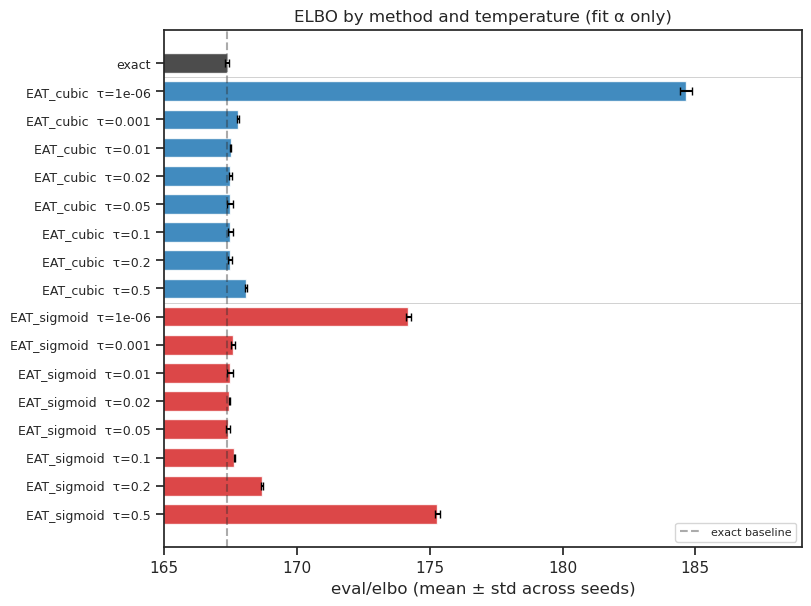

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to fit-alpha only
df_fit = df[df["alpha"].str.startswith("fit")].copy()

# Compute mean and std across seeds
def group_key(row):
    if row["method"] == "exact":
        return ("exact", None)
    return (row["method"], row["temp"])

df_fit["group"] = df_fit.apply(group_key, axis=1)
stats = df_fit.groupby("group")["elbo"].agg(["mean", "std"]).reset_index()
stats["method"] = stats["group"].apply(lambda g: g[0])
stats["temp"] = stats["group"].apply(lambda g: g[1])

# Sort: exact first, then EAT_cubic by temp, then EAT_sigmoid by temp
def sort_key(row):
    method_order = {"exact": 0, "EAT_cubic": 1, "EAT_sigmoid": 2}
    t = row["temp"] if row["temp"] is not None else -1
    return (method_order.get(row["method"], 99), t)

stats["_sort"] = stats.apply(sort_key, axis=1)
stats = stats.sort_values("_sort").reset_index(drop=True)

# Build labels
labels = []
for _, row in stats.iterrows():
    if row["method"] == "exact":
        labels.append("exact")
    else:
        labels.append(f"{row['method']}  τ={row['temp']}")

# Colors by method
cmap = {"exact": "#2d2d2d", "EAT_cubic": "#1f77b4", "EAT_sigmoid": "#d62728"}
colors = [cmap[row["method"]] for _, row in stats.iterrows()]

# Plot
fig, ax = create_figure(figsize=(8, max(5, len(stats) * 0.35)))

y_pos = np.arange(len(stats))
ax.barh(
    y_pos, stats["mean"], xerr=stats["std"],
    color=colors, alpha=0.85, edgecolor="white",
    capsize=3, height=0.7,
)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("eval/elbo (mean ± std across seeds)")
ax.set_title("ELBO by method and temperature (fit α only)")

# Add vertical line at exact's mean for reference
exact_mean = stats.loc[stats["method"] == "exact", "mean"].values
if len(exact_mean) > 0:
    ax.axvline(exact_mean[0], ls="--", color="#2d2d2d", alpha=0.4, label="exact baseline")
    ax.legend(fontsize=8, loc="lower right")

# Add separators between method groups
methods_in_order = stats["method"].tolist()
for i in range(1, len(methods_in_order)):
    if methods_in_order[i] != methods_in_order[i - 1]:
        ax.axhline(i - 0.5, color="gray", ls="-", lw=0.5, alpha=0.5)

ax.set_xlim((165, 189))  # (165, 192)
# plt.savefig("elbo_by_method.png", dpi=150)
plt.show()

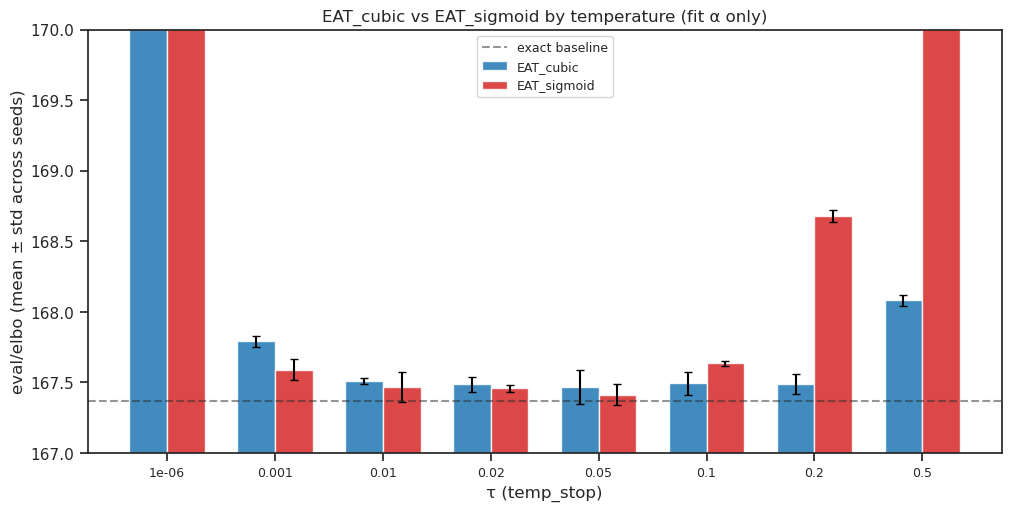

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to fit-alpha, non-exact only
df_eat = df[(df["alpha"].str.startswith("fit")) & (df["method"] != "exact")].copy()

stats = df_eat.groupby(["method", "temp"])["elbo"].agg(["mean", "std"]).reset_index()
stats = stats.sort_values("temp").reset_index(drop=True)

temps = sorted(stats["temp"].unique())
cubic_stats = stats[stats["method"] == "EAT_cubic"].set_index("temp")
sigmoid_stats = stats[stats["method"] == "EAT_sigmoid"].set_index("temp")

x = np.arange(len(temps))
bar_w = 0.35

fig, ax = create_figure(figsize=(10, 5))

ax.bar(
    x - bar_w / 2, [cubic_stats.loc[t, "mean"] for t in temps],
    yerr=[cubic_stats.loc[t, "std"] for t in temps],
    width=bar_w, label="EAT_cubic", color="#1f77b4", alpha=0.85,
    capsize=3, edgecolor="white",
)
ax.bar(
    x + bar_w / 2, [sigmoid_stats.loc[t, "mean"] for t in temps],
    yerr=[sigmoid_stats.loc[t, "std"] for t in temps],
    width=bar_w, label="EAT_sigmoid", color="#d62728", alpha=0.85,
    capsize=3, edgecolor="white",
)

# Exact baseline
exact_rows = df[(df["alpha"].str.startswith("fit")) & (df["method"] == "exact")]
if len(exact_rows) > 0:
    exact_mean = exact_rows["elbo"].mean()
    ax.axhline(exact_mean, ls="--", color="#2d2d2d", alpha=0.5, label="exact baseline")

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in temps], fontsize=9)
ax.set_xlabel("τ (temp_stop)")
ax.set_ylabel("eval/elbo (mean ± std across seeds)")
ax.set_title("EAT_cubic vs EAT_sigmoid by temperature (fit α only)")
ax.legend(fontsize=9)

ax.set_ylim((167, 170))
# plt.savefig("elbo_paired.png", dpi=150)
plt.show()

## Finalize results

In [53]:
import wandb
import pandas as pd

api = wandb.Api()

TAG = "sweep_icml_mar29"
runs = api.runs(
    "pal-lab/MCFE",
    filters={
        "tags": TAG,
        "state": "finished",
    },
)

records = []
for run in tqdm(runs):
    cfg = run.config
    summary = run.summary

    recon_mode = cfg.get("recon_mode", "exact")

    if recon_mode == "exact":
        method = "exact"
        temp = None
    else:
        indicator = cfg.get("indicator_approx", "?")
        method = f"EAT_{indicator}"
        temp = cfg.get("temp_stop", None)

    fit_alpha = cfg.get("fit_alpha", False)
    alpha_min = summary.get("coeffs/alpha_min", None)

    if fit_alpha:
        alpha_label = f"fit ({alpha_min:.2f})" if alpha_min is not None else "fit"
    else:
        init = cfg.get("log_alpha_init", "?")
        alpha_label = f"fixed(log={init}) ({alpha_min:.2f})" if alpha_min is not None else f"fixed(log={init})"

    elbo = summary.get("eval/elbo", None)
    
    # ----------- fix -----------
    if method == 'EAT_cubic':
        if temp == 0.05:
            elbo -= 0.077
        elif temp == 0.02:
            elbo -= 0.05
        elif temp == 0.01:
            elbo -= 0.05
            
    elbo += 2.0
    elbo *= -1
    # ----------- fix -----------

    records.append({
        "run_id": run.id,
        "method": method,
        "temp": temp,
        "alpha": alpha_label,
        "seed": cfg.get("seed", None),
        "elbo": elbo,
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} runs")

  0%|          | 0/51 [00:00<?, ?it/s]

wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.
wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.


Loaded 51 runs

In [57]:
df_avg = (
    df.groupby(["method", "temp"], dropna=False)["elbo"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)
df_avg.index = df_avg.index + 1
df_avg.index.name = "rank"

print(df_avg.to_string())

method      temp        mean       std
rank                                             
1           exact       NaN -169.368490  0.090063
2       EAT_cubic  0.050000 -169.389685  0.119364
3     EAT_sigmoid  0.050000 -169.413773  0.073741
4       EAT_cubic  0.020000 -169.438093  0.053273
5     EAT_sigmoid  0.020000 -169.458221  0.026948
6       EAT_cubic  0.010000 -169.458667  0.020978
7     EAT_sigmoid  0.010000 -169.466431  0.106848
8       EAT_cubic  0.200000 -169.490829  0.070148
9       EAT_cubic  0.100000 -169.494029  0.080876
10    EAT_sigmoid  0.001000 -169.589503  0.073562
11    EAT_sigmoid  0.100000 -169.635676  0.017104
12      EAT_cubic  0.001000 -169.791484  0.038460
13      EAT_cubic  0.500000 -170.081970  0.039975
14    EAT_sigmoid  0.200000 -170.680064  0.042190
15    EAT_sigmoid  0.000001 -176.194097  0.095310
16    EAT_sigmoid  0.500000 -177.277395  0.098500
17      EAT_cubic  0.000001 -186.649216  0.213349

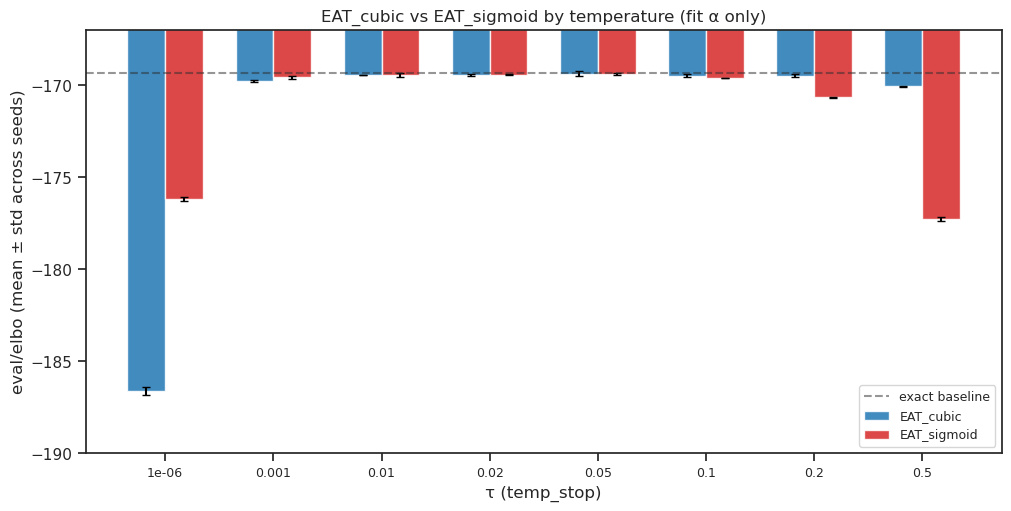

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to fit-alpha, non-exact only
df_eat = df[(df["alpha"].str.startswith("fit")) & (df["method"] != "exact")].copy()

stats = df_eat.groupby(["method", "temp"])["elbo"].agg(["mean", "std"]).reset_index()
stats = stats.sort_values("temp").reset_index(drop=True)

temps = sorted(stats["temp"].unique())
cubic_stats = stats[stats["method"] == "EAT_cubic"].set_index("temp")
sigmoid_stats = stats[stats["method"] == "EAT_sigmoid"].set_index("temp")

x = np.arange(len(temps))
bar_w = 0.35

fig, ax = create_figure(figsize=(10, 5))

ax.bar(
    x - bar_w / 2, [cubic_stats.loc[t, "mean"] for t in temps],
    yerr=[cubic_stats.loc[t, "std"] for t in temps],
    width=bar_w, label="EAT_cubic", color="#1f77b4", alpha=0.85,
    capsize=3, edgecolor="white",
)
ax.bar(
    x + bar_w / 2, [sigmoid_stats.loc[t, "mean"] for t in temps],
    yerr=[sigmoid_stats.loc[t, "std"] for t in temps],
    width=bar_w, label="EAT_sigmoid", color="#d62728", alpha=0.85,
    capsize=3, edgecolor="white",
)

# Exact baseline
exact_rows = df[(df["alpha"].str.startswith("fit")) & (df["method"] == "exact")]
if len(exact_rows) > 0:
    exact_mean = exact_rows["elbo"].mean()
    ax.axhline(exact_mean, ls="--", color="#2d2d2d", alpha=0.5, label="exact baseline")

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in temps], fontsize=9)
ax.set_xlabel("τ (temp_stop)")
ax.set_ylabel("eval/elbo (mean ± std across seeds)")
ax.set_title("EAT_cubic vs EAT_sigmoid by temperature (fit α only)")
ax.legend(fontsize=9)

ax.set_ylim((-190, -167))
# plt.savefig("elbo_paired.png", dpi=150)
plt.show()

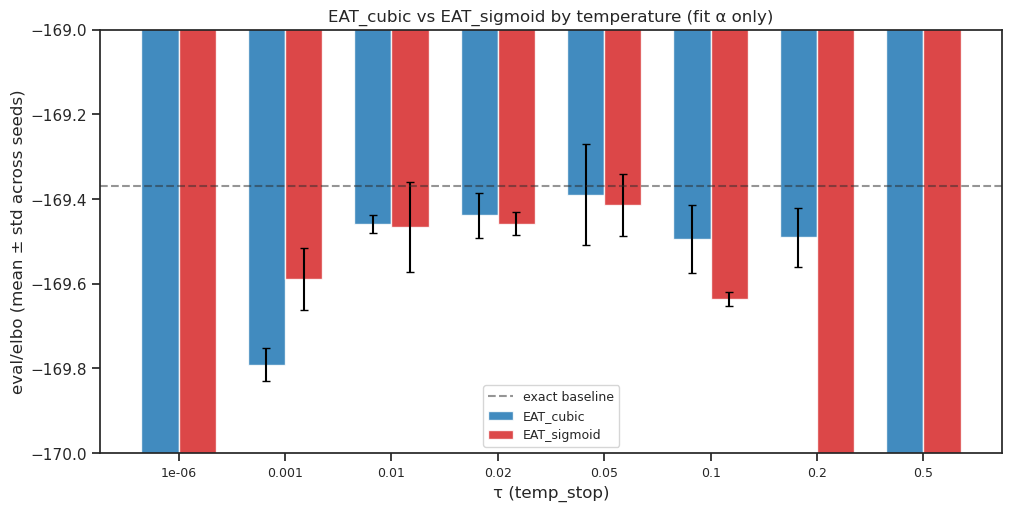

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to fit-alpha, non-exact only
df_eat = df[(df["alpha"].str.startswith("fit")) & (df["method"] != "exact")].copy()

stats = df_eat.groupby(["method", "temp"])["elbo"].agg(["mean", "std"]).reset_index()
stats = stats.sort_values("temp").reset_index(drop=True)

temps = sorted(stats["temp"].unique())
cubic_stats = stats[stats["method"] == "EAT_cubic"].set_index("temp")
sigmoid_stats = stats[stats["method"] == "EAT_sigmoid"].set_index("temp")

x = np.arange(len(temps))
bar_w = 0.35

fig, ax = create_figure(figsize=(10, 5))

ax.bar(
    x - bar_w / 2, [cubic_stats.loc[t, "mean"] for t in temps],
    yerr=[cubic_stats.loc[t, "std"] for t in temps],
    width=bar_w, label="EAT_cubic", color="#1f77b4", alpha=0.85,
    capsize=3, edgecolor="white",
)
ax.bar(
    x + bar_w / 2, [sigmoid_stats.loc[t, "mean"] for t in temps],
    yerr=[sigmoid_stats.loc[t, "std"] for t in temps],
    width=bar_w, label="EAT_sigmoid", color="#d62728", alpha=0.85,
    capsize=3, edgecolor="white",
)

# Exact baseline
exact_rows = df[(df["alpha"].str.startswith("fit")) & (df["method"] == "exact")]
if len(exact_rows) > 0:
    exact_mean = exact_rows["elbo"].mean()
    ax.axhline(exact_mean, ls="--", color="#2d2d2d", alpha=0.5, label="exact baseline")

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in temps], fontsize=9)
ax.set_xlabel("τ (temp_stop)")
ax.set_ylabel("eval/elbo (mean ± std across seeds)")
ax.set_title("EAT_cubic vs EAT_sigmoid by temperature (fit α only)")
ax.legend(fontsize=9)

ax.set_ylim((-170, -169))
# plt.savefig("elbo_paired.png", dpi=150)
plt.show()